# Notebook 3: Faster R-CNN Training

This notebook loads the shared dataset split, defines the Faster R-CNN dataset/dataloaders, trains the model, and saves a checkpoint.

In [ ]:
import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.amp as amp
from torch.utils.data import DataLoader


def resolve_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "medical_detection").exists():
            return candidate

    kaggle_candidate = Path("/kaggle/working/model-comparison-for-lesion-detection")
    if (kaggle_candidate / "medical_detection").exists():
        return kaggle_candidate

    raise FileNotFoundError("Could not locate a project root containing the medical_detection package.")


PROJECT_ROOT = resolve_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from medical_detection import (
    COMMON_COMPARISON_TRAINING_CONFIG,
    FRCNNDataset,
    FRCNNDatasetConfig,
    ProjectPaths,
    build_faster_rcnn_model,
    build_dataset_index,
    class_names_from_csv,
    collate_fn,
    evaluate_faster_rcnn,
    load_split_filenames,
    records_from_filenames,
    resolve_dataset_root,
    )

DATASET_ROOT = resolve_dataset_root(PROJECT_ROOT)
paths = ProjectPaths(project_root=PROJECT_ROOT, dataset_root=DATASET_ROOT)
class_names = class_names_from_csv(paths.csv_path)
nc = len(class_names)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
comparison_train_config = COMMON_COMPARISON_TRAINING_CONFIG.copy()
FASTER_RCNN_CONFIG = {
    "epochs": 40,
    "optimizer": "SGD",
    "lr": 0.005,
    "momentum": 0.9,
    "weight_decay": 0.0005,
    "lr_step_epochs": [10, 16],
    "patience": 40,
}
FRCNN_SPLIT_SUFFIX = ""
FRCNN_SPLIT_LABEL = FRCNN_SPLIT_SUFFIX.lstrip("_") or "baseline"

random.seed(comparison_train_config["seed"])
torch.manual_seed(comparison_train_config["seed"])
torch.use_deterministic_algorithms(True, warn_only=True)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(comparison_train_config["seed"])
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No CUDA GPU detected. Training will run on CPU.")
print(f"PROJECT_ROOT: {paths.project_root}")
print(f"DATASET_ROOT: {paths.dataset_root}")
print(f"Number of classes: {nc}")
print(f"Faster R-CNN split suffix: {FRCNN_SPLIT_SUFFIX or '(baseline)'}")
print("Shared comparison config:", comparison_train_config)
print("Faster R-CNN config:", FASTER_RCNN_CONFIG)

CUDA available: True
GPU: NVIDIA GeForce RTX 5080
PROJECT_ROOT: c:\Users\Domagoj\Downloads\malter
DATASET_ROOT: c:\Users\Domagoj\Downloads\malter
Number of classes: 11
Faster R-CNN split suffix: (baseline)
Shared comparison config: {'epochs': 100, 'seed': 42, 'patience': 30, 'optimizer': 'AdamW', 'lr0': 0.001, 'lrf': 0.05, 'weight_decay': 0.0005, 'warmup_epochs': 5, 'cos_lr': True, 'workers': 4}
Faster R-CNN config: {'epochs': 40, 'optimizer': 'SGD', 'lr': 0.002, 'momentum': 0.9, 'weight_decay': 0.0005, 'lr_step_epochs': [25, 35], 'patience': 40}


In [2]:
dataset_index = build_dataset_index(paths.image_dir, paths.label_dir, paths.csv_path, group_size=25)
train_records = records_from_filenames(dataset_index, load_split_filenames(paths.splits_dir / f"train{FRCNN_SPLIT_SUFFIX}.txt"))
val_records = records_from_filenames(dataset_index, load_split_filenames(paths.splits_dir / f"val{FRCNN_SPLIT_SUFFIX}.txt"))
test_records = records_from_filenames(dataset_index, load_split_filenames(paths.splits_dir / f"test{FRCNN_SPLIT_SUFFIX}.txt"))

print(f"Split variant: {FRCNN_SPLIT_LABEL}")
print(f"Train records: {len(train_records)}")
print(f"Validation records: {len(val_records)}")
print(f"Test records: {len(test_records)}")
print(f"Train negatives kept for training: {sum(1 for record in train_records if not record.has_annotations)}")
print(f"Validation negatives kept for evaluation: {sum(1 for record in val_records if not record.has_annotations)}")
print(f"Test negatives kept for evaluation: {sum(1 for record in test_records if not record.has_annotations)}")

Split variant: baseline
Train records: 12931
Validation records: 3700
Test records: 1850
Train negatives kept for training: 4530
Validation negatives kept for evaluation: 1156
Test negatives kept for evaluation: 505


In [3]:
batch_size = 8 if torch.cuda.is_available() else 1
num_workers = comparison_train_config["workers"] if torch.cuda.is_available() else 0

train_dataset_frcnn = FRCNNDataset(train_records, FRCNNDatasetConfig(include_empty_images=True, train=True))
val_dataset_frcnn = FRCNNDataset(val_records, FRCNNDatasetConfig(include_empty_images=True, train=False))
test_dataset_frcnn = FRCNNDataset(test_records, FRCNNDatasetConfig(include_empty_images=True, train=False))

train_empty_count = sum(1 for record in train_dataset_frcnn.records if not record.has_annotations)
train_empty_ratio = (train_empty_count / len(train_dataset_frcnn)) if len(train_dataset_frcnn) else 0.0
print(f"Faster R-CNN training set: {len(train_dataset_frcnn)} images, {train_empty_count} empty ({train_empty_ratio:.2%})")

Faster R-CNN training set: 12931 images, 4530 empty (35.03%)


In [4]:
train_dataloader_frcnn = DataLoader(train_dataset_frcnn, batch_size=batch_size, shuffle=True, num_workers=num_workers, collate_fn=collate_fn)
val_dataloader_frcnn = DataLoader(val_dataset_frcnn, batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collate_fn)
test_dataloader_frcnn = DataLoader(test_dataset_frcnn, batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collate_fn)

print(len(train_dataset_frcnn), len(val_dataset_frcnn), len(test_dataset_frcnn))

12931 3700 1850


In [5]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.device_count() > 0:
    print("Device names:", [torch.cuda.get_device_name(index) for index in range(torch.cuda.device_count())])

for split_name, records in (("train", train_records), ("val", val_records), ("test", test_records)):
    positives = sum(1 for record in records if record.has_annotations)
    negatives = len(records) - positives
    print(f"{split_name}: {len(records)} images, {positives} positive, {negatives} negative")

sample_image, sample_target = train_dataset_frcnn[0]
print("Sample image shape:", tuple(sample_image.shape))
print("Sample target keys:", list(sample_target.keys()))
print("Sample boxes shape:", tuple(sample_target["boxes"].shape))
print("Sample labels:", sample_target["labels"].tolist())
print(f"Train dataset includes empty images: {any(not record.has_annotations for record in train_dataset_frcnn.records)}")

PyTorch: 2.11.0+cu130
CUDA available: True
CUDA device count: 1
Device names: ['NVIDIA GeForce RTX 5080']
train: 12931 images, 8401 positive, 4530 negative
val: 3700 images, 2544 positive, 1156 negative
test: 1850 images, 1345 positive, 505 negative
Sample image shape: (3, 576, 576)
Sample target keys: ['boxes', 'labels', 'image_id', 'iscrowd', 'area']
Sample boxes shape: (0, 4)
Sample labels: []
Train dataset includes empty images: True


In [6]:
all_labels = sorted({int(label.item()) for _, target in train_dataset_frcnn for label in target["labels"]})
print("Observed training labels:", all_labels)

Observed training labels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


In [7]:
def evaluate_model(model, dataloader, device):
    return evaluate_faster_rcnn(model, dataloader, device, class_metrics=True)

In [ ]:
checkpoint_dir = paths.runs_dir / ("frcnn" if FRCNN_SPLIT_LABEL == "baseline" else f"frcnn_{FRCNN_SPLIT_LABEL}")
checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_checkpoint_path = checkpoint_dir / "faster_rcnn_best.pth"
latest_checkpoint_path = checkpoint_dir / "faster_rcnn_latest.pth"
training_history_path = checkpoint_dir / "training_history.json"

num_classes = nc + 1
frcnn_model = build_faster_rcnn_model(num_classes=num_classes, pretrained=True)
frcnn_model.to(device)

optimizer = torch.optim.SGD(
    [parameter for parameter in frcnn_model.parameters() if parameter.requires_grad],
    lr=FASTER_RCNN_CONFIG["lr"],
    momentum=FASTER_RCNN_CONFIG["momentum"],
    weight_decay=FASTER_RCNN_CONFIG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=FASTER_RCNN_CONFIG["lr_step_epochs"],
    gamma=0.1,
)
scaler = amp.GradScaler("cuda", enabled=torch.cuda.is_available())

start_epoch = 0
best_map = 0.0
best_map50 = 0.0
best_fitness = float("-inf")
epochs_without_improvement = 0
history = []
num_epochs = FASTER_RCNN_CONFIG["epochs"]
resume_training = False

if resume_training and latest_checkpoint_path.exists():
    checkpoint = torch.load(latest_checkpoint_path, map_location=device)
    frcnn_model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = int(checkpoint["epoch"]) + 1
    best_map = float(checkpoint.get("best_map", 0.0))
    best_map50 = float(checkpoint.get("best_map50", 0.0))
    best_fitness = float(checkpoint.get("best_fitness", 0.1 * best_map50 + 0.9 * best_map))
    epochs_without_improvement = int(checkpoint.get("epochs_without_improvement", 0))
    history = checkpoint.get("history", [])
    print(f"Resuming from epoch {start_epoch}")
else:
    print(f"Starting Faster R-CNN training with split variant: {FRCNN_SPLIT_LABEL}")

print("Faster R-CNN optimizer:", optimizer.__class__.__name__)
print("Faster R-CNN scheduler:", scheduler.__class__.__name__)

for epoch in range(start_epoch, num_epochs):
    frcnn_model.train()
    running_loss = 0.0
    current_lr = float(optimizer.param_groups[0]["lr"])

    for batch_index, (images, targets) in enumerate(train_dataloader_frcnn):
        images = [image.to(device) for image in images]
        targets = [{key: value.to(device) for key, value in target.items()} for target in targets]

        optimizer.zero_grad(set_to_none=True)
        with amp.autocast("cuda", enabled=torch.cuda.is_available()):
            loss_dict = frcnn_model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += float(losses.item())

    print(f"Epoch {epoch + 1}/{num_epochs}, batch {batch_index}/{len(train_dataloader_frcnn)}, loss={losses.item():.4f}")
    avg_train_loss = running_loss / max(len(train_dataloader_frcnn), 1)
    val_metrics = evaluate_model(frcnn_model, val_dataloader_frcnn, device)
    val_map = float(val_metrics["map"].item())
    val_map50 = float(val_metrics["map_50"].item())
    val_fitness = 0.1 * val_map50 + 0.9 * val_map

    epoch_record = {
        "epoch": epoch,
        "train_loss": avg_train_loss,
        "val_map": val_map,
        "val_map50": val_map50,
        "val_fitness": val_fitness,
        "lr": current_lr,
        "split_label": FRCNN_SPLIT_LABEL,
        "frcnn_config": FASTER_RCNN_CONFIG,
    }
    history.append(epoch_record)
    print(epoch_record)

    improved = val_fitness > best_fitness + 1e-9
    if improved:
        best_map = val_map
        best_map50 = val_map50
        best_fitness = val_fitness
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    checkpoint_payload = {
        "epoch": epoch,
        "model_state_dict": frcnn_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "num_classes": num_classes,
        "split_label": FRCNN_SPLIT_LABEL,
        "frcnn_config": FASTER_RCNN_CONFIG,
        "best_map": best_map,
        "best_map50": best_map50,
        "best_fitness": best_fitness,
        "epochs_without_improvement": epochs_without_improvement,
        "history": history,
    }
    torch.save(checkpoint_payload, latest_checkpoint_path)

    if improved:
        torch.save(checkpoint_payload, best_checkpoint_path)
        print(
            f"New best model saved with val_fitness={best_fitness:.4f} "
            f"(mAP50-95={best_map:.4f}, mAP50={best_map50:.4f})"
        )

    training_history_path.write_text(json.dumps(history, indent=2), encoding="utf-8")
    scheduler.step()

    if epochs_without_improvement >= FASTER_RCNN_CONFIG["patience"]:
        print(
            f"Early stopping at epoch {epoch + 1} after "
            f"{FASTER_RCNN_CONFIG['patience']} epochs without validation fitness improvement."
        )
        break

print(f"Training history saved to {training_history_path}")

Resuming from epoch 11
Faster R-CNN optimizer: SGD
Faster R-CNN scheduler: MultiStepLR
Epoch 12/40, batch 1616/1617, loss=0.2035
{'epoch': 11, 'train_loss': 0.08008695622138914, 'val_map': 0.20934900641441345, 'val_map50': 0.4457322359085083, 'val_fitness': 0.23298732936382294, 'lr': 0.005, 'split_label': 'baseline', 'frcnn_config': {'epochs': 40, 'optimizer': 'SGD', 'lr': 0.002, 'momentum': 0.9, 'weight_decay': 0.0005, 'lr_step_epochs': [25, 35], 'patience': 40}}
Epoch 13/40, batch 1616/1617, loss=0.0211
{'epoch': 12, 'train_loss': 0.07867150427399222, 'val_map': 0.22898846864700317, 'val_map50': 0.4609346091747284, 'val_fitness': 0.2521830826997757, 'lr': 0.005, 'split_label': 'baseline', 'frcnn_config': {'epochs': 40, 'optimizer': 'SGD', 'lr': 0.002, 'momentum': 0.9, 'weight_decay': 0.0005, 'lr_step_epochs': [25, 35], 'patience': 40}}
Epoch 14/40, batch 1616/1617, loss=0.1357
{'epoch': 13, 'train_loss': 0.08521721745370649, 'val_map': 0.20787066221237183, 'val_map50': 0.436638116836

KeyboardInterrupt: 

In [ ]:
print("Latest checkpoint:", latest_checkpoint_path)
print("Best checkpoint:", best_checkpoint_path)

Latest checkpoint: c:\Users\Domagoj\Downloads\malter\runs\frcnn\faster_rcnn_latest.pth
Best checkpoint: c:\Users\Domagoj\Downloads\malter\runs\frcnn\faster_rcnn_best.pth


In [ ]:
checkpoint = torch.load(best_checkpoint_path, map_location=device)
frcnn_model.load_state_dict(checkpoint["model_state_dict"])
frcnn_model.to(device)
frcnn_model.eval()
print(
    f"Loaded best model from epoch {checkpoint['epoch']} with "
    f"best_map {checkpoint['best_map']:.4f}, "
    f"best_map50 {checkpoint.get('best_map50', 0.0):.4f}, "
    f"best_fitness {checkpoint.get('best_fitness', checkpoint['best_map']):.4f}"
)

Loaded best model from epoch 25 with best_map 0.1839, best_map50 0.3808, best_fitness 0.2036


In [ ]:
checkpoint_files = sorted(checkpoint_dir.glob("*.pth"), key=lambda path: path.stat().st_mtime)
print("Faster R-CNN checkpoint directory:")
print(checkpoint_dir)
print("Latest checkpoint path:")
print(latest_checkpoint_path)
print("Best checkpoint path:")
print(best_checkpoint_path)
print("Checkpoint files found:")
for path in checkpoint_files:
    print(" ", path)

Faster R-CNN checkpoint directory:
c:\Users\Domagoj\Downloads\malter\runs\frcnn
Latest checkpoint path:
c:\Users\Domagoj\Downloads\malter\runs\frcnn\faster_rcnn_latest.pth
Best checkpoint path:
c:\Users\Domagoj\Downloads\malter\runs\frcnn\faster_rcnn_best.pth
Checkpoint files found:
  c:\Users\Domagoj\Downloads\malter\runs\frcnn\faster_rcnn_best.pth
  c:\Users\Domagoj\Downloads\malter\runs\frcnn\faster_rcnn_latest.pth


In [ ]:
frcnn_model.to(device)
frcnn_model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [ ]:
all_outputs = []
all_targets = []

with torch.no_grad():
    for images, targets in val_dataloader_frcnn:
        images = [image.to(device) for image in images]
        outputs = frcnn_model(images)
        all_outputs.extend(outputs)
        all_targets.extend(targets)

print(f"Collected {len(all_outputs)} validation predictions")

Collected 3700 validation predictions


In [ ]:
results = evaluate_model(frcnn_model, val_dataloader_frcnn, device)
print(results)

{'map': tensor(0.1841), 'map_50': tensor(0.3807), 'map_75': tensor(0.1537), 'map_small': tensor(0.0314), 'map_medium': tensor(0.1148), 'map_large': tensor(0.1879), 'mar_1': tensor(0.2881), 'mar_10': tensor(0.3476), 'mar_100': tensor(0.3490), 'mar_small': tensor(0.0596), 'mar_medium': tensor(0.1980), 'mar_large': tensor(0.3626), 'map_per_class': tensor([0.1422, 0.1708, 0.4032, 0.2387, 0.1385, 0.2463, 0.1715, 0.1972, 0.0017,
        0.0766, 0.1840, 0.2381]), 'mar_100_per_class': tensor([0.2681, 0.2867, 0.5966, 0.3623, 0.2710, 0.5393, 0.3298, 0.3541, 0.0857,
        0.3237, 0.3619, 0.4086]), 'classes': tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=torch.int32)}


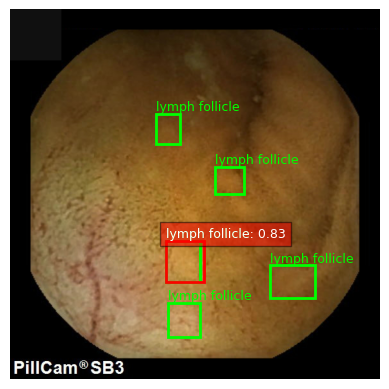

In [ ]:
frcnn_model.eval()
visual_image, visual_target = val_dataset_frcnn[0]

with torch.no_grad():
    output = frcnn_model([visual_image.to(device)])[0]

image_np = visual_image.cpu().permute(1, 2, 0).numpy()
plt.imshow(image_np)
ax = plt.gca()

for gt_box, gt_label in zip(visual_target["boxes"], visual_target["labels"]):
    x1, y1, x2, y2 = gt_box.tolist()
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="lime", facecolor="none")
    ax.add_patch(rect)
    ax.text(x1, max(0, y1 - 5), class_names[int(gt_label.item()) - 1], color="lime", fontsize=9)

for box, score, label in zip(output["boxes"], output["scores"], output["labels"]):
    score_value = float(score.item())
    if score_value < 0.5:
        continue
    x1, y1, x2, y2 = box.cpu().tolist()
    class_index = int(label.item()) - 1
    class_name = class_names[class_index] if 0 <= class_index < len(class_names) else f"class_{label.item()}"
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="red", facecolor="none")
    ax.add_patch(rect)
    ax.text(x1, y1 - 5, f"{class_name}: {score_value:.2f}", color="white", fontsize=9, bbox=dict(facecolor="red", alpha=0.5))

plt.axis("off")
plt.show()